In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import matplotlib.pyplot as plt
import seaborn as sns
# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/sharmajicoder/used-car-price-prediction-dataset/used_car_price_prediction_1M.csv


In [2]:
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

Dataset Link:- https://www.kaggle.com/datasets/sharmajicoder/used-car-price-prediction-dataset/data

In [3]:
# Disabling Scientific Notation
np.set_printoptions(suppress=True)
pd.options.display.float_format = '{:.2f}'.format

In [4]:
data = pd.read_csv("/kaggle/input/datasets/sharmajicoder/used-car-price-prediction-dataset/used_car_price_prediction_1M.csv")

# 1. Understanding Data

In [5]:
df = pd.DataFrame(data)
df.head()

,Brand,Model,Year,Mileage_kmpl,Engine_CC,Horsepower,Fuel_Type,Transmission,Owner_Type,Color,City,Kms_Driven,Insurance_Valid,Service_History,Accidents,Tax_Paid,Number_of_Doors,Seats,Registration_Age,Price
0,Toyota,Camry,2001,19.62,1396.56,NaN,Hybrid,Automatic,First,Grey,Chennai,500928,1,1,0,1,4,5,24,353189.60
1,Hyundai,i20,2012,19.48,1130.77,137.02,Petrol,NaN,First,Grey,Mumbai,211510,0,1,0,1,4,5,13,959694.26
2,Mahindra,Bolero,2008,17.47,1766.47,142.90,NaN,Automatic,First,Black,Kolkata,333999,1,0,0,1,5,5,17,292022.93
3,BMW,X1,2015,21.30,NaN,49.78,NaN,Manual,First,White,Pune,225930,1,1,3,1,4,5,10,2949453.46
4,Honda,Civic,2022,18.33,1239.33,121.51,Diesel,Manual,Second,White,Kolkata,43404,1,0,0,1,5,5,3,636520.80


In [6]:
df.shape

(1005000, 20)

In [7]:
print("Total duplicates in dataset : ",df.duplicated().sum())

Total duplicates in dataset :  5000


In [8]:
df.isna().sum()[df.isna().sum() > 0]

Mileage_kmpl    80390
Engine_CC       80403
Horsepower      80403
Fuel_Type       78733
Transmission    80385
Color           80419
City            80430
dtype: int64

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1005000 entries, 0 to 1004999
Data columns (total 20 columns):
 #   Column            Non-Null Count    Dtype  
---  ------            --------------    -----  
 0   Brand             1005000 non-null  object 
 1   Model             1005000 non-null  object 
 2   Year              1005000 non-null  int64  
 3   Mileage_kmpl      924610 non-null   float64
 4   Engine_CC         924597 non-null   float64
 5   Horsepower        924597 non-null   float64
 6   Fuel_Type         926267 non-null   object 
 7   Transmission      924615 non-null   object 
 8   Owner_Type        1005000 non-null  object 
 9   Color             924581 non-null   object 
 10  City              924570 non-null   object 
 11  Kms_Driven        1005000 non-null  int64  
 12  Insurance_Valid   1005000 non-null  int64  
 13  Service_History   1005000 non-null  int64  
 14  Accidents         1005000 non-null  int64  
 15  Tax_Paid          1005000 non-null  int64  
 16  

In [10]:
df[['Year', 'Registration_Age']].corr()

,Year,Registration_Age
Year,1.00,-1.00
Registration_Age,-1.00,1.00


Since one can be calculated from the other, keeping both adds redundant information.

In [11]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Year,1005000.00,2012.00,7.21,2000.00,2006.00,2012.00,2018.00,2024.00
Mileage_kmpl,924610.00,18.00,3.99,5.00,15.30,18.00,20.69,36.28
Engine_CC,924597.00,1506.63,386.03,800.00,1230.41,1500.18,1769.60,3362.02
Horsepower,924597.00,120.57,36.78,-18.51,94.84,120.05,145.48,290.25
Kms_Driven,1005000.00,202863.89,175370.54,5000.00,84555.00,166313.00,286380.00,4368000.00
Insurance_Valid,1005000.00,0.85,0.36,0.00,1.00,1.00,1.00,1.00
Service_History,1005000.00,0.75,0.43,0.00,1.00,1.00,1.00,1.00
Accidents,1005000.00,0.30,0.55,0.00,0.00,0.00,1.00,5.00
Tax_Paid,1005000.00,0.90,0.30,0.00,1.00,1.00,1.00,1.00
Number_of_Doors,1005000.00,4.25,0.70,2.00,4.00,4.00,5.00,5.00


**With the help of above we found that**
* Cars min mileage is 5 and max is approx 36.3
* Columns `Horsepower` contains some redundant (negative) values which will fix in cleaning
* `Insurance_Valid`,`Service_History`,and `Tax_Paid` columns contains integer based boolean values

In [12]:
len(df[df["Horsepower"] < 0])

32

We need to fix this

#### Checking Spelling

In [13]:
cat_cols = df.select_dtypes(include='object').columns
print(len(cat_cols))

7


In [14]:
for col in cat_cols:
    print(f"\n{col}")
    print("Unique values are : ",df[col].unique())
    print("Unique values count : ",df[col].nunique())


Brand
Unique values are :  ['Toyota' 'Hyundai' 'Mahindra' 'BMW' 'Honda' 'Volkswagen' 'Audi'
 'Mercedes' 'Kia' 'Ford' 'Nissan' 'Tata' 'Skoda' ' BMW ' ' Kia ' ' Ford '
 ' Volkswagen ' ' Skoda ' ' Tata ' ' Mercedes ' ' Hyundai ' ' Audi '
 ' Honda ' ' Nissan ' ' Toyota ' ' Mahindra ']
Unique values count :  26

Model
Unique values are :  ['Camry' 'i20' 'Bolero' 'X1' 'Civic' 'Creta' 'Taigun' 'A4' 'E-Class'
 'Seltos' 'Q5' 'Figo' 'Sunny' 'EcoSport' 'Nexon' 'Harrier' 'X3' 'City'
 'Endeavour' '3 Series' 'Yaris' 'XUV700' 'Verna' 'Sonet' 'Magnite'
 'Octavia' 'Punch' 'Kicks' 'Kushaq' 'Amaze' 'C-Class' 'Polo' 'Slavia'
 'Carens' 'Corolla' 'Scorpio' 'Q3' 'GLA' 'Virtus']
Unique values count :  39

Fuel_Type
Unique values are :  ['Hybrid' 'Petrol' nan 'Diesel' 'CNG' 'Electric' 'electrik' ' Diesel'
 'PETROL' 'petrol' 'hybridd' 'diesel ']
Unique values count :  11

Transmission
Unique values are :  ['Automatic' nan 'Manual']
Unique values count :  2

Owner_Type
Unique values are :  ['First' 'Second' 'Fo

# 2. Data Cleaning

## 2.1 Remove leading/trailing spaces from `Brand` values

In [15]:
df["Brand"] = df["Brand"].str.strip()
print("Toatl unique values : ",df["Brand"].nunique())
df["Brand"].unique()

Toatl unique values :  13


array(['Toyota', 'Hyundai', 'Mahindra', 'BMW', 'Honda', 'Volkswagen',
       'Audi', 'Mercedes', 'Kia', 'Ford', 'Nissan', 'Tata', 'Skoda'],
      dtype=object)

The output confirms that unnecessary spaces have been removed successfully. As a result, the number of unique Brand values has reduced from 26 to 13, eliminating duplicate categories created by inconsistent spacing.

## 2.2 Clean the values and correcting spelling mistakes from `Fuel_Type`

In [16]:
# Remove leading/trailing spaces
df["Fuel_Type"] = df["Fuel_Type"].str.strip()

# Standardize capitalization
df["Fuel_Type"] = df["Fuel_Type"].str.title()

# Correct spelling mistakes
df["Fuel_Type"] = df["Fuel_Type"].replace({
    "Electrik": "Electric",
    "Hybridd": "Hybrid"
})

In [17]:
# Verify the cleaned values
print("Unique values are:", df["Fuel_Type"].unique())
print("Unique values count:", df["Fuel_Type"].nunique())

Unique values are: ['Hybrid' 'Petrol' nan 'Diesel' 'Cng' 'Electric']
Unique values count: 5


## 2.3 Convert negative `Horsepower` values to positive

In [18]:
df["Horsepower"] = df["Horsepower"].abs()

## 2.4 Removing Duplicates

In [19]:
df = df.drop_duplicates()
df.shape

(1000000, 20)

## 3.5 Removing column which contains same information but in a different way

In [20]:
df = df.drop(columns=['Year'])

## 2.5 Filling missing values

In [21]:
# Fill NaN values in categorical columns with mode
categorical_cols = df.select_dtypes(include=["object", "category"]).columns

for col in categorical_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

# Fill NaN values in numerical columns with median
numerical_cols = df.select_dtypes(include=["number"]).columns

for col in numerical_cols:
    df[col] = df[col].fillna(df[col].median())

In [22]:
print("Total null vlaues : ",df.isna().sum()[df.isna().sum() > 0])

Total null vlaues :  Series([], dtype: int64)


# 3. EDA

In [23]:
# Columns based on Data Type 
num_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()

# Numerical cols which are more good for countplot
extra_num_cols = ['Insurance_Valid', 'Service_History','Accidents','Tax_Paid','Number_of_Doors','Seats']

# Categorical columns
cat_cols = df.select_dtypes(include=['object', 'bool']).columns.tolist()

In [24]:
num_cols

['Mileage_kmpl',
 'Engine_CC',
 'Horsepower',
 'Kms_Driven',
 'Insurance_Valid',
 'Service_History',
 'Accidents',
 'Tax_Paid',
 'Number_of_Doors',
 'Seats',
 'Registration_Age',
 'Price']

In [25]:
# Total Numerical Columns
print(f"Total Numerical Columns: {len(num_cols)}")

# Total Categorical Columns
print(f"Total Categorical Columns: {len(cat_cols)}")

Total Numerical Columns: 12
Total Categorical Columns: 7


## 3.1 Univariate Analysis

### 3.1.1 Numerical columns(Histograms & Boxplots

In [26]:
sample_df = df.sample(15000)

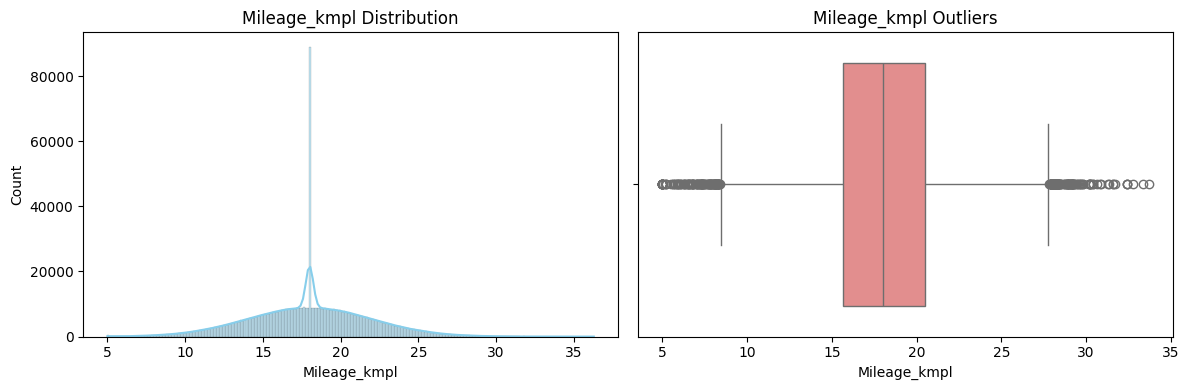

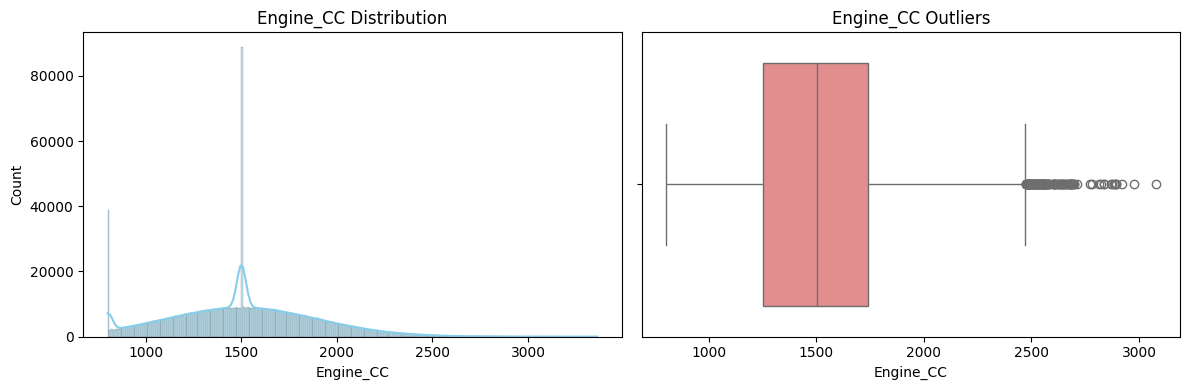

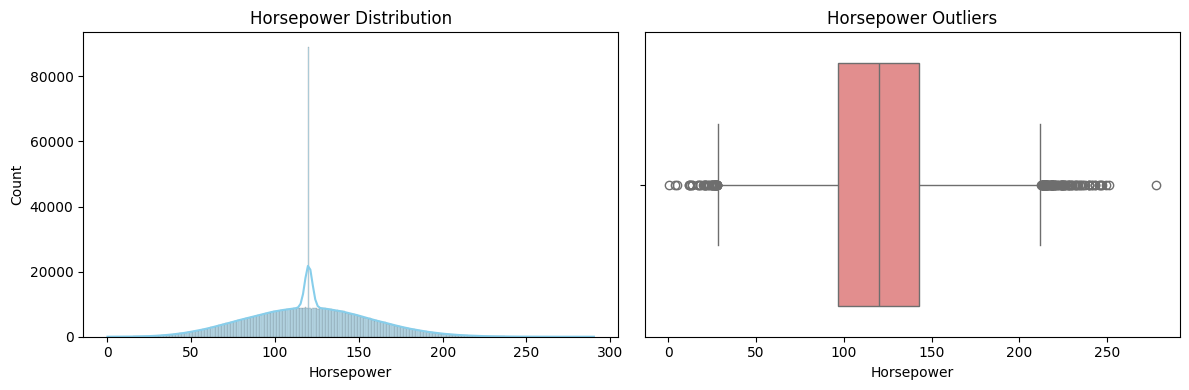

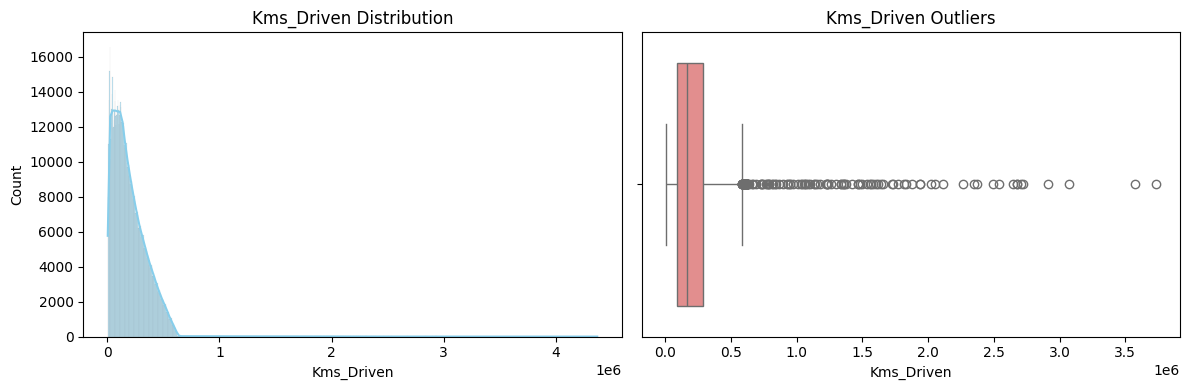

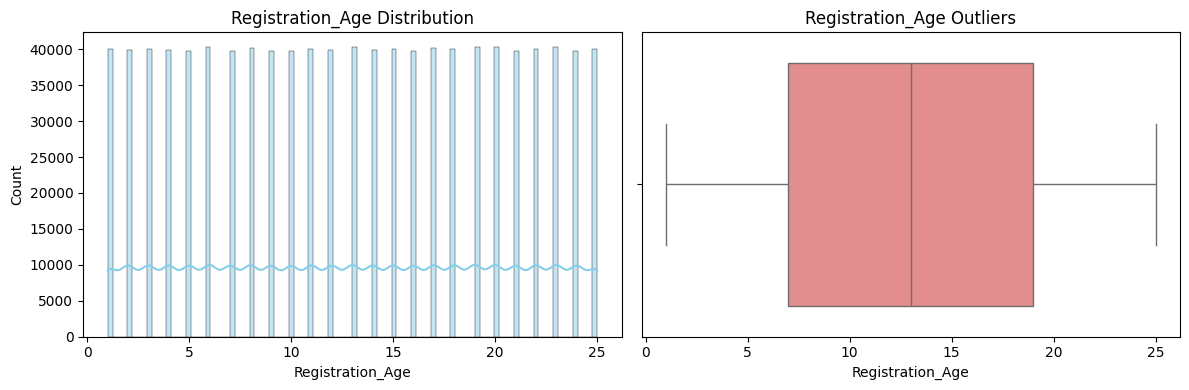

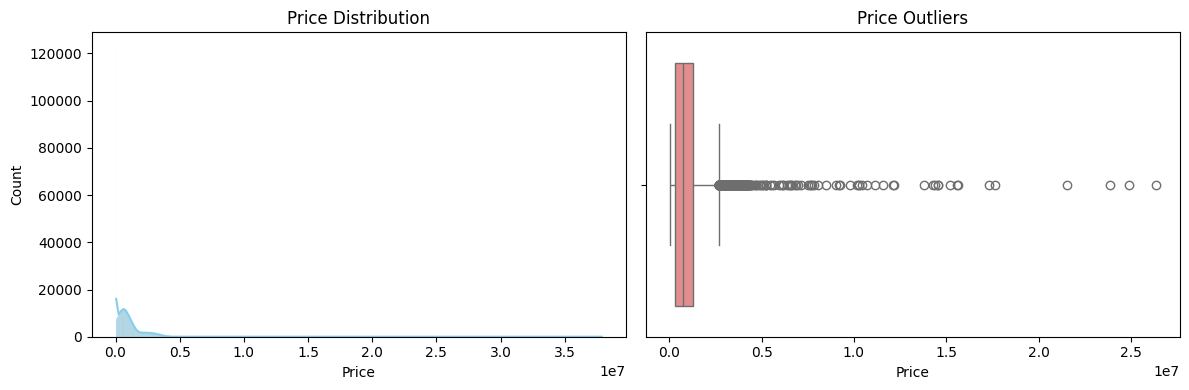

In [27]:
# Plot Histograms and Boxplots side-by-side for each numerical column
for col in num_cols:
    if col not in extra_num_cols:
        fig, axes = plt.subplots(1, 2, figsize=(12, 4))
        
        # Histogram with KDE curve
        sns.histplot(data=df, x=col, kde=True, ax=axes[0], color='skyblue')
        axes[0].set_title(f'{col} Distribution')
        
        # Boxplot for outliers
        sns.boxplot(data=sample_df, x=col, ax=axes[1], color='lightcoral')
        axes[1].set_title(f'{col} Outliers')
        
        plt.tight_layout()
        plt.show()

**Outlier & Skewness Analysis**
* `Year`: Approximately uniform distribution; no transformation required.
* `Mileage_kmpl`: Slightly right-skewed with some outliers; minor impact.
* `Engine_CC`: Moderately right-skewed; outliers present but valid (high-end vehicles).
* `Horsepower`: Slight right-skew with few extreme values; no removal needed.
* `Registration_Age`: Nearly uniform distribution; no transformation required.
* `Price`: Highly right-skewed with significant outliers; transformation may be required.

### 3.1.2 Categorical Columns (Count plots)

In [28]:
import math

def count_plot(cols):
    n = len(cols)
    rows = math.ceil(n / 2)

    plt.figure(figsize=(14, 5 * rows))

    for i, col in enumerate(cols, 1):
        plt.subplot(rows, 2, i)

        sns.countplot(
            data=sample_df,
            x=col,
            order=sample_df[col].value_counts().index,
            palette='viridis',
            legend=True
        )

        plt.title(f'{col} Frequency (100K Sample)')
        plt.xticks(rotation=45)

    plt.tight_layout()
    plt.show()

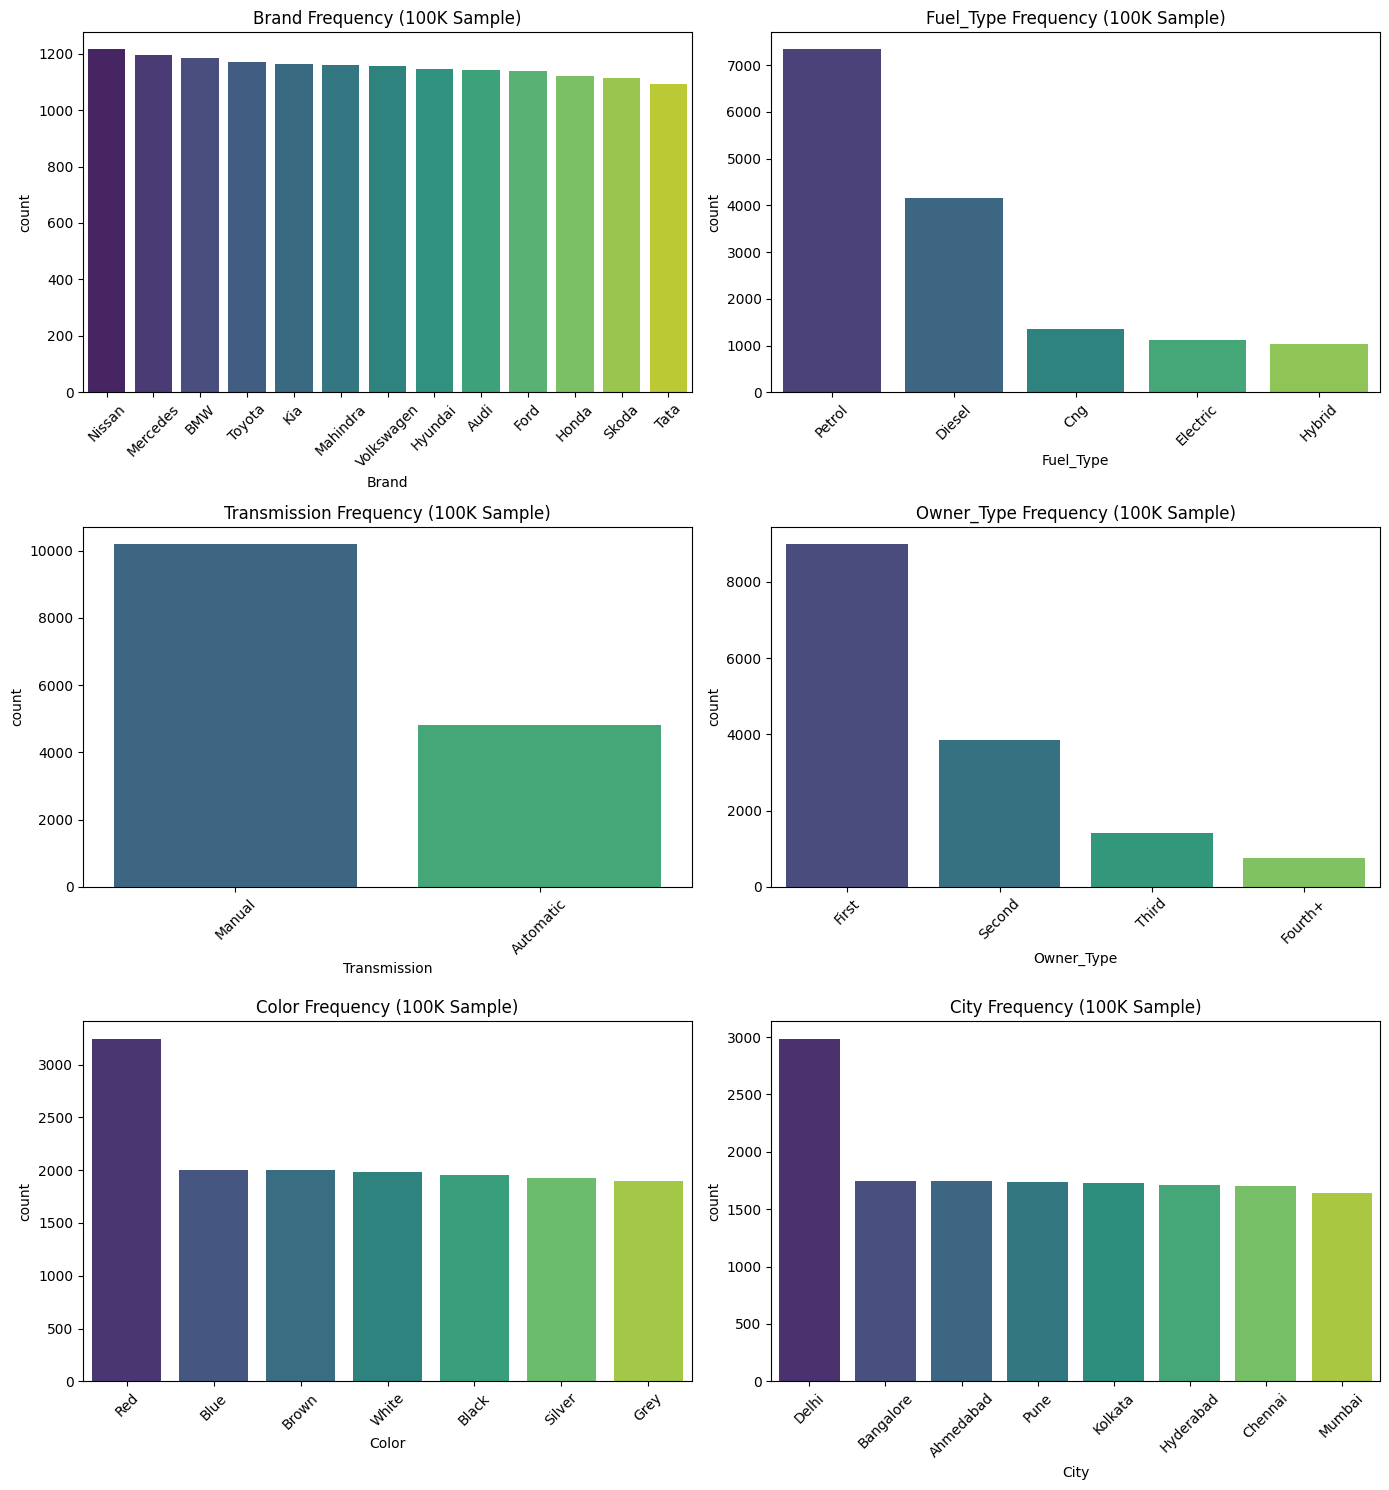

In [29]:
if "Model" in cat_cols:
    cat_cols.remove("Model")
count_plot(cat_cols)

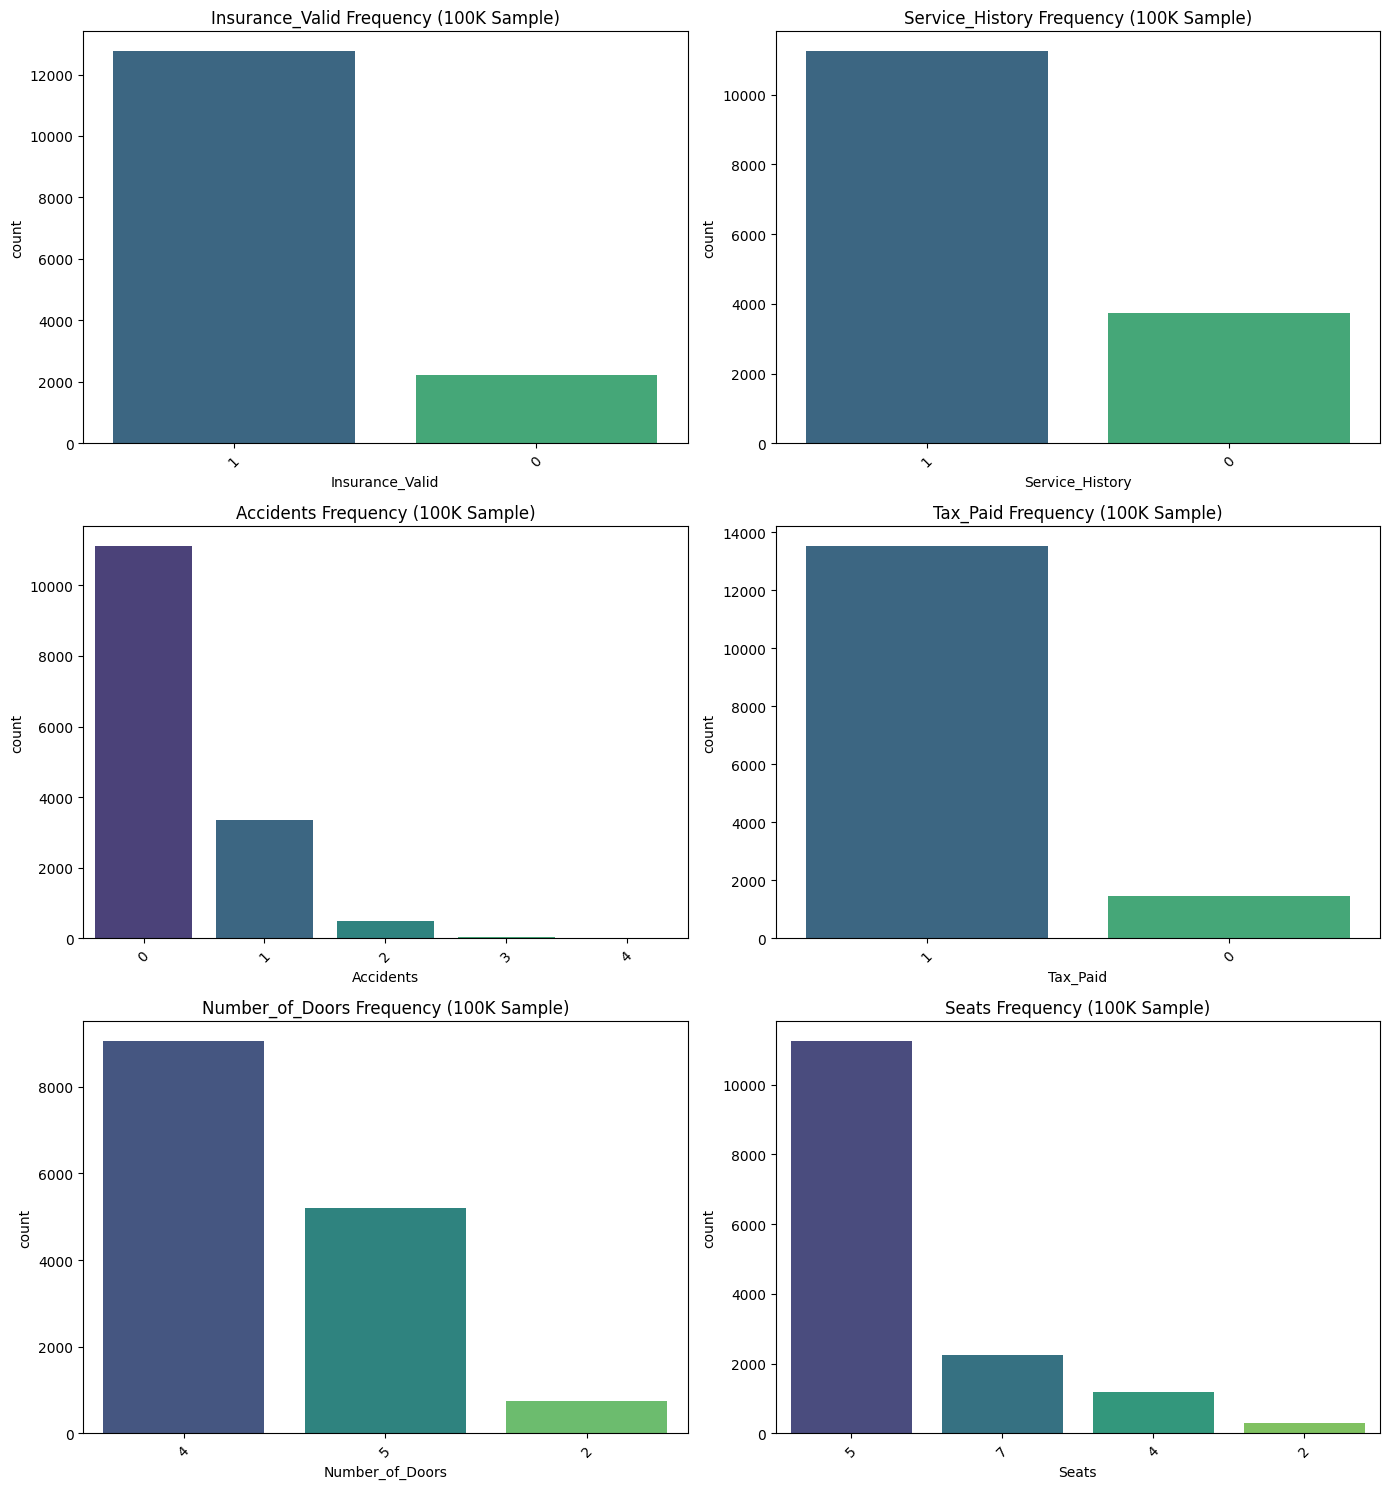

In [30]:
count_plot(extra_num_cols)

## 3.2 Bivariate Analysis

### 3.2.1 Numerical vs Numerical

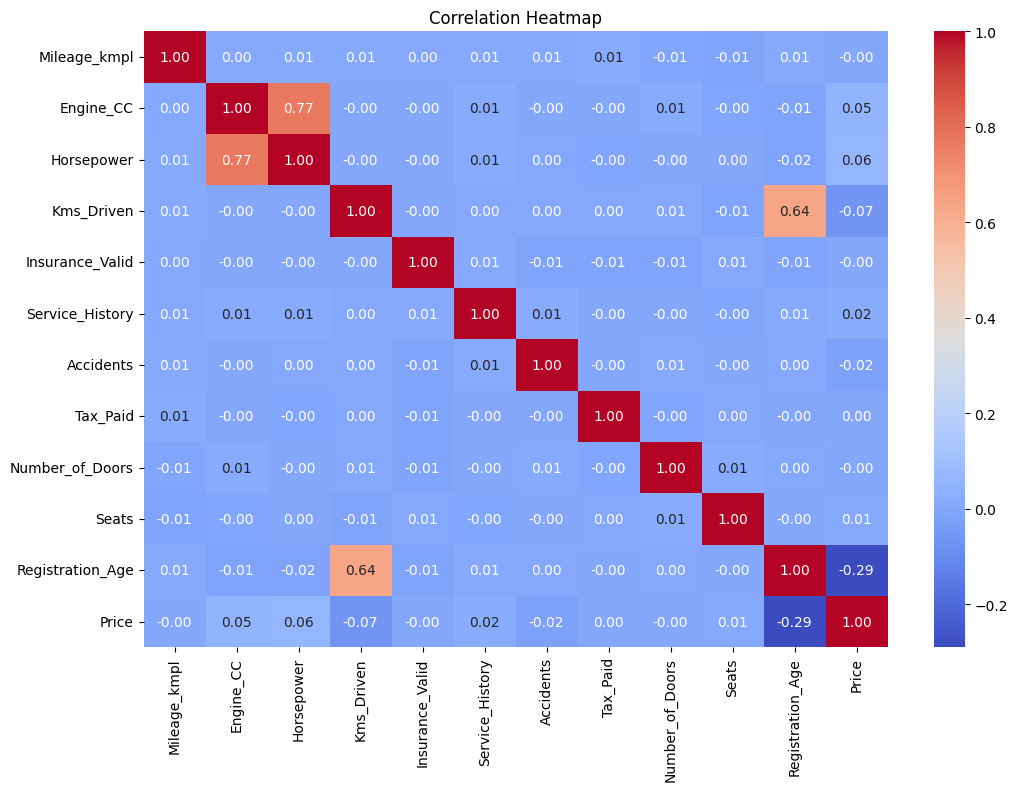

In [31]:
plt.figure(figsize=(12,8))

sns.heatmap(
    sample_df[num_cols].corr(),
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title("Correlation Heatmap")
plt.show()

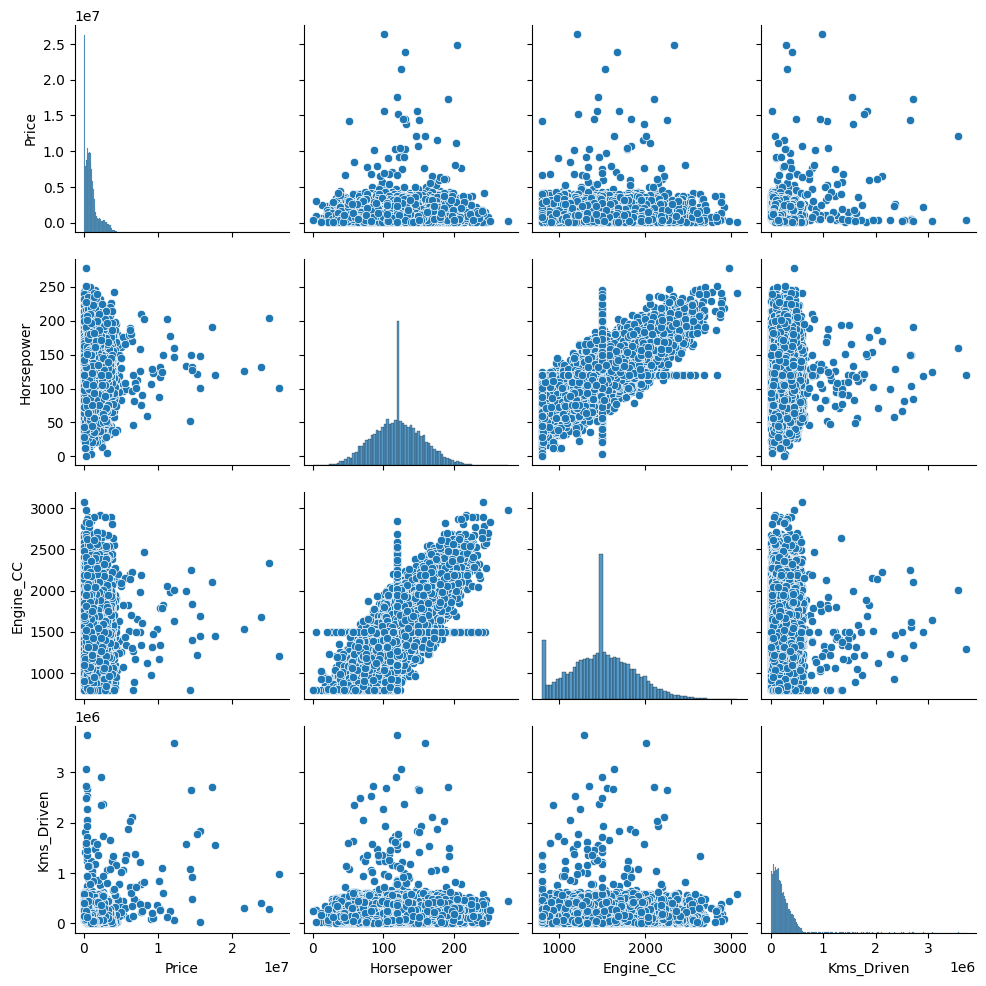

In [32]:
cols = ['Price','Horsepower', 'Engine_CC', 'Kms_Driven']

sns.pairplot(sample_df[cols])
plt.show()

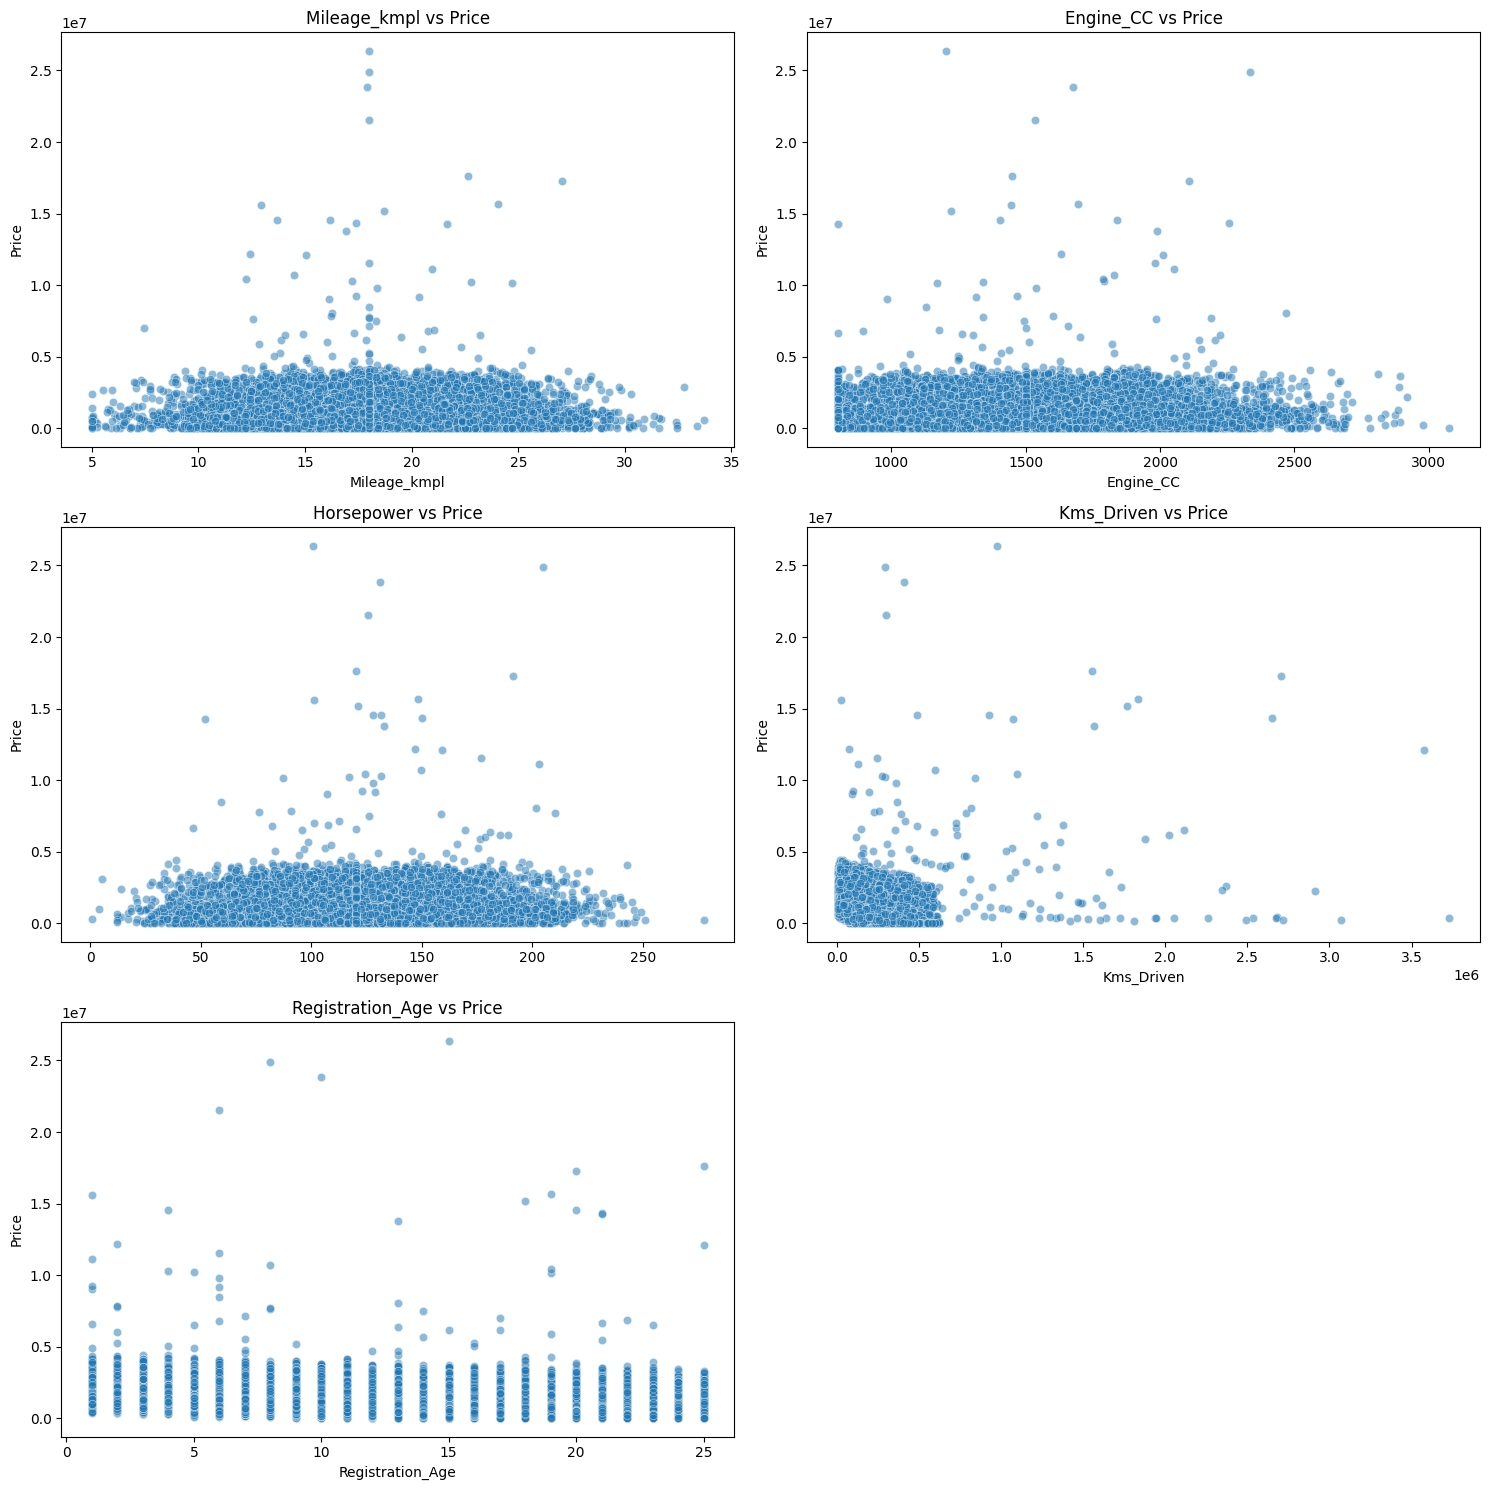

In [33]:
import math

def scatter_plot(cols, target):
    n = len(cols)
    rows = math.ceil(n / 2)

    plt.figure(figsize=(15, 5 * rows))

    for i, col in enumerate(cols, 1):
        plt.subplot(rows, 2, i)

        sns.scatterplot(
            data=sample_df,
            x=col,
            y=target,
            alpha=0.5
        )

        plt.title(f"{col} vs {target}")

    plt.tight_layout()
    plt.show()

num_features = [
    'Mileage_kmpl',
    'Engine_CC',
    'Horsepower',
    'Kms_Driven',
    'Registration_Age'
]

scatter_plot(num_features, 'Price')

### 3.2.2. Categorical vs Categorical

Count Plot

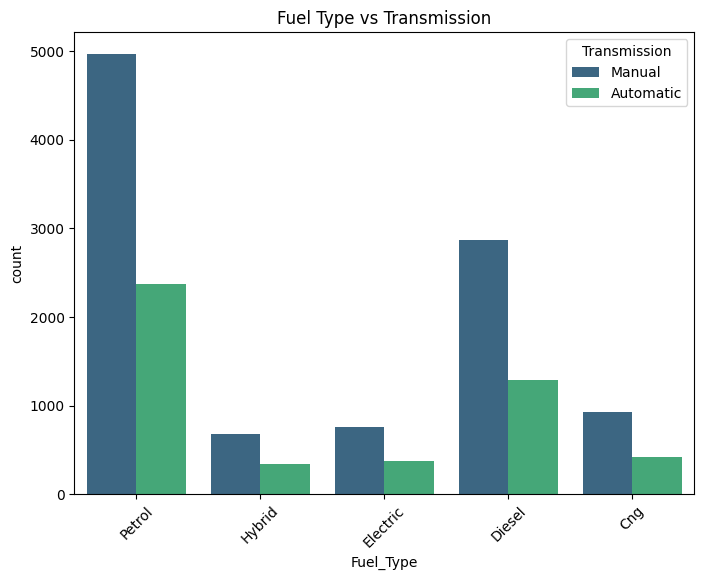

In [34]:
plt.figure(figsize=(8,6))

sns.countplot(
    data=sample_df,
    x='Fuel_Type',
    hue='Transmission',
    palette='viridis'
)

plt.title("Fuel Type vs Transmission")
plt.xticks(rotation=45)
plt.show()

Crosstab (Frequency Table)

In [35]:
pd.crosstab(
    sample_df['Fuel_Type'],
    sample_df['Transmission']
)

Transmission,Automatic,Manual
Fuel_Type,,
Cng,423,930
Diesel,1291,2866
Electric,374,754
Hybrid,345,683
Petrol,2370,4964


Heatmap of Crosstab

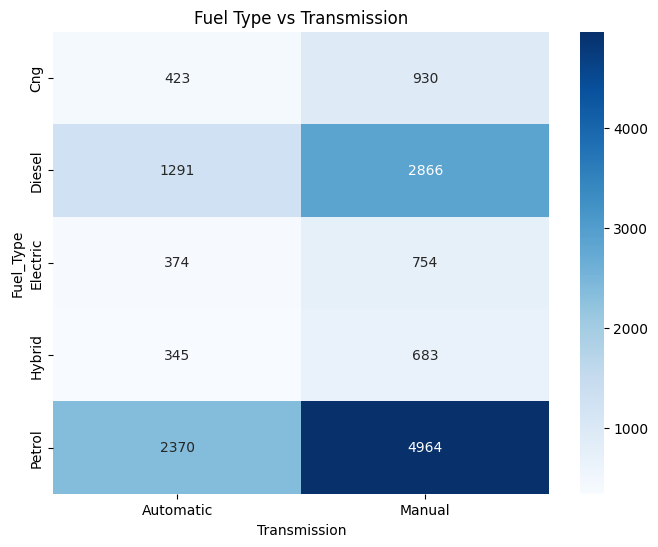

In [36]:
cross_tab = pd.crosstab(
    sample_df['Fuel_Type'],
    sample_df['Transmission']
)

plt.figure(figsize=(8,6))

sns.heatmap(
    cross_tab,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title("Fuel Type vs Transmission")
plt.show()

### 3.2.3. Numerical vs Categorical

(a) Box Plot

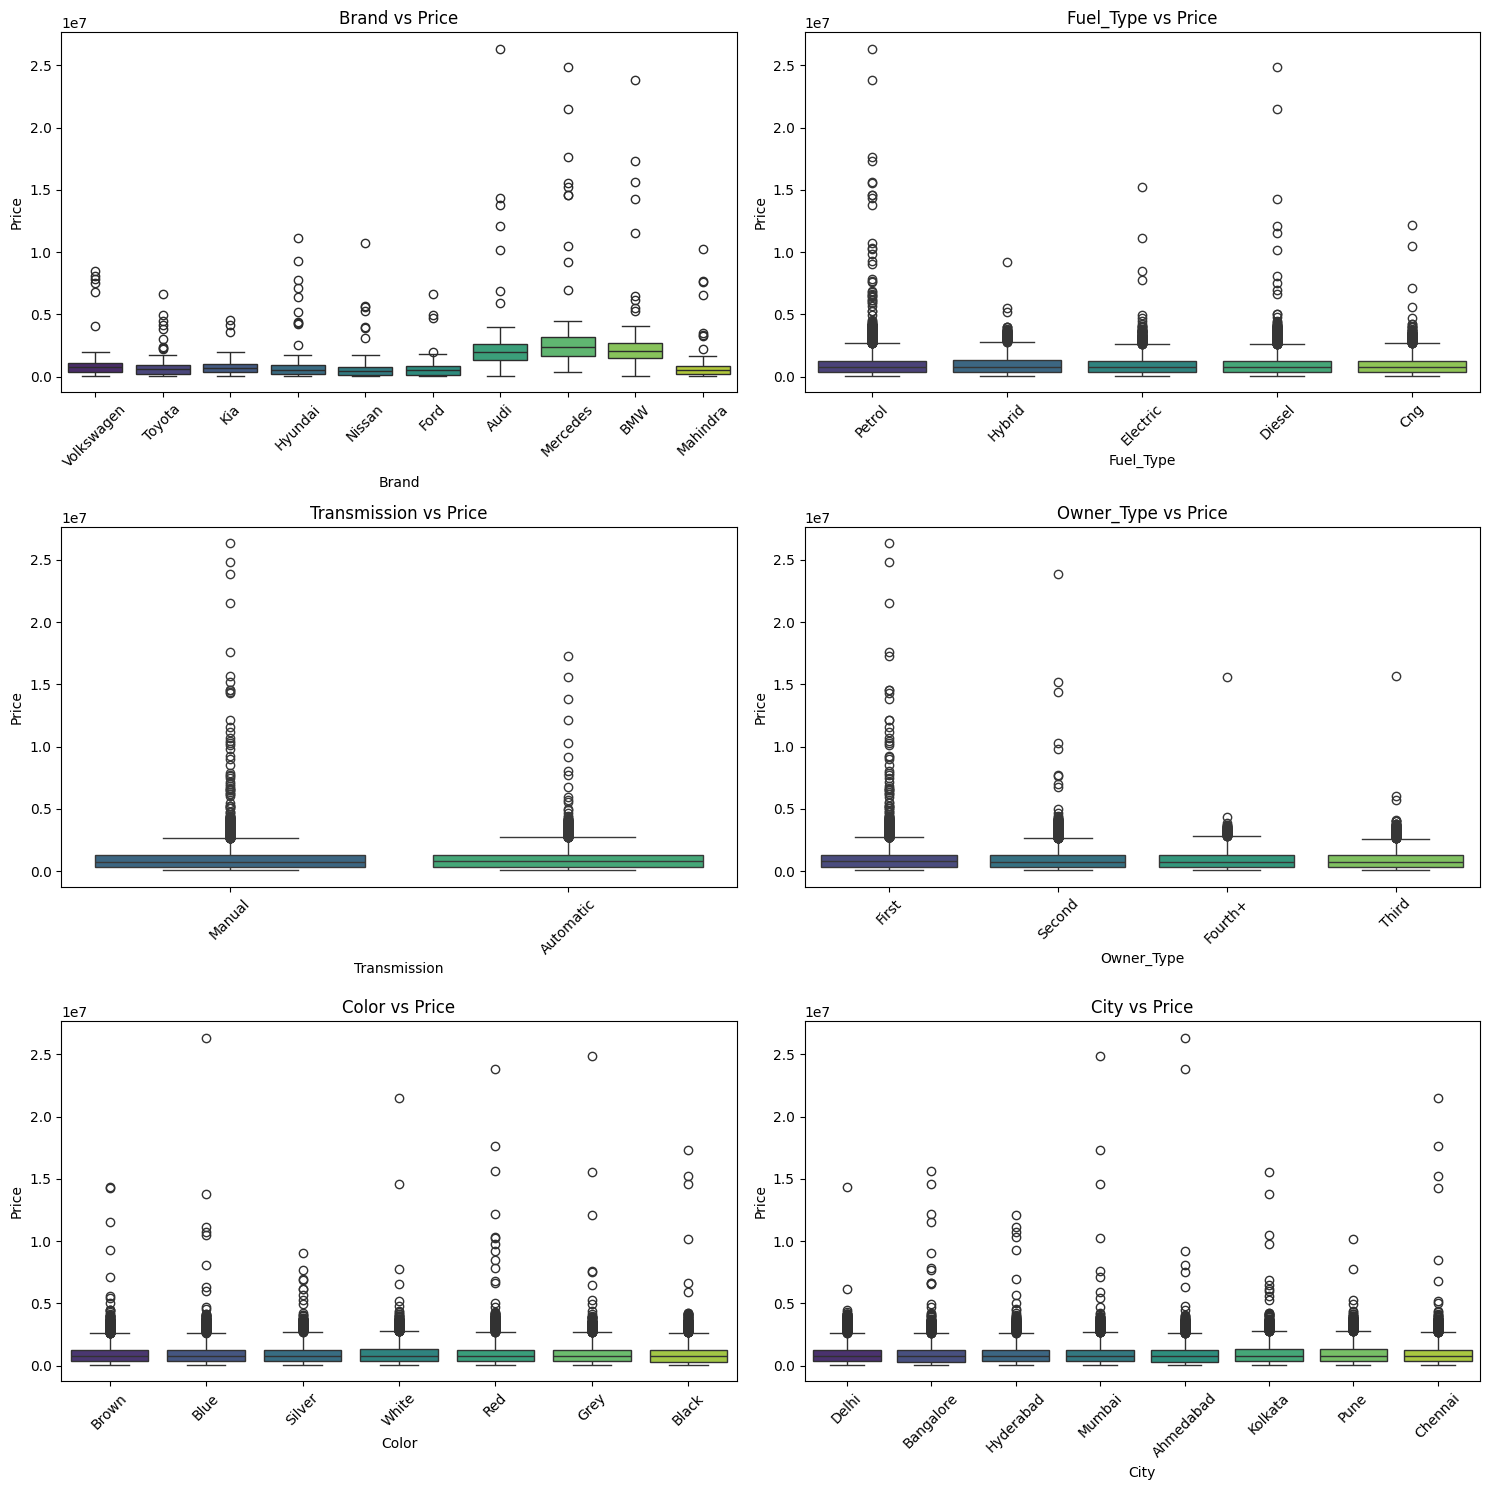

In [37]:
import math

def box_plot(cols, target):
    n = len(cols)
    rows = math.ceil(n / 2)

    plt.figure(figsize=(15, 5 * rows))

    for i, col in enumerate(cols, 1):
        plt.subplot(rows, 2, i)

        top = sample_df[col].value_counts().head(10).index

        sns.boxplot(
            data=sample_df[sample_df[col].isin(top)],
            x=col,
            y=target,
            hue=col,
            palette='viridis',
            legend=False
        )

        plt.title(f"{col} vs {target}")
        plt.xticks(rotation=45)

    plt.tight_layout()
    plt.show()

box_plot(cat_cols, 'Price')

(b) Violin Plot

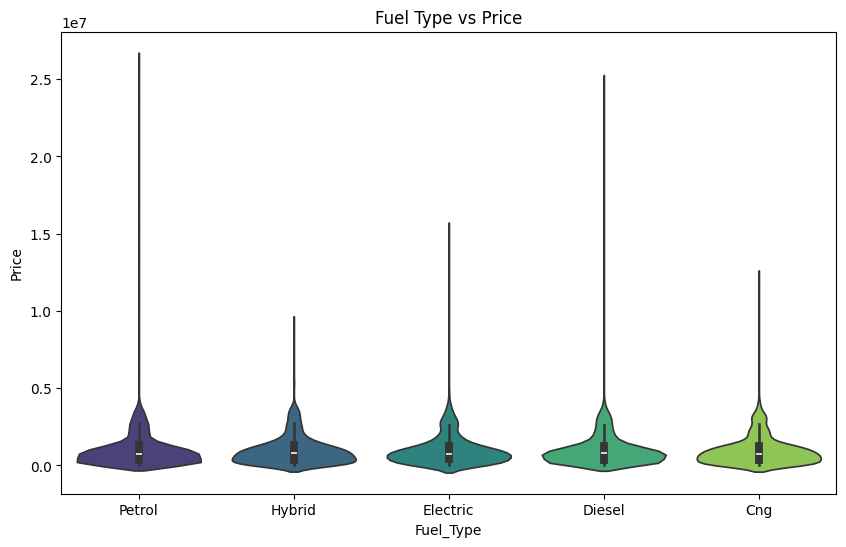

In [38]:
plt.figure(figsize=(10,6))

sns.violinplot(
    data=sample_df,
    x='Fuel_Type',
    y='Price',
    hue='Fuel_Type',
    palette='viridis',
    legend=False
)

plt.title("Fuel Type vs Price")
plt.show()

(c) Bar Plot (Average Price)

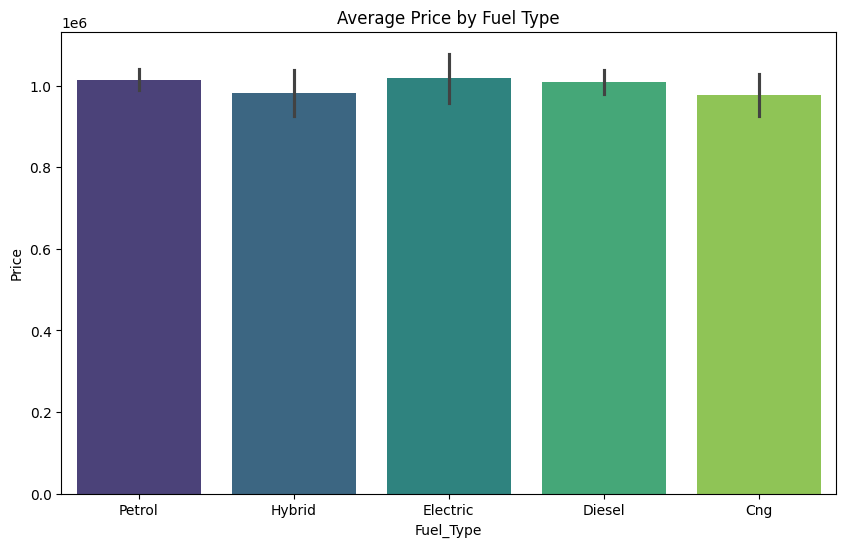

In [39]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=sample_df,
    x='Fuel_Type',
    y='Price',
    hue='Fuel_Type',
    estimator='mean',
    palette='viridis',
    legend=False
)

plt.title("Average Price by Fuel Type")
plt.show()

## 3.3 Multivariate Analysis

### 1. Pair Plot

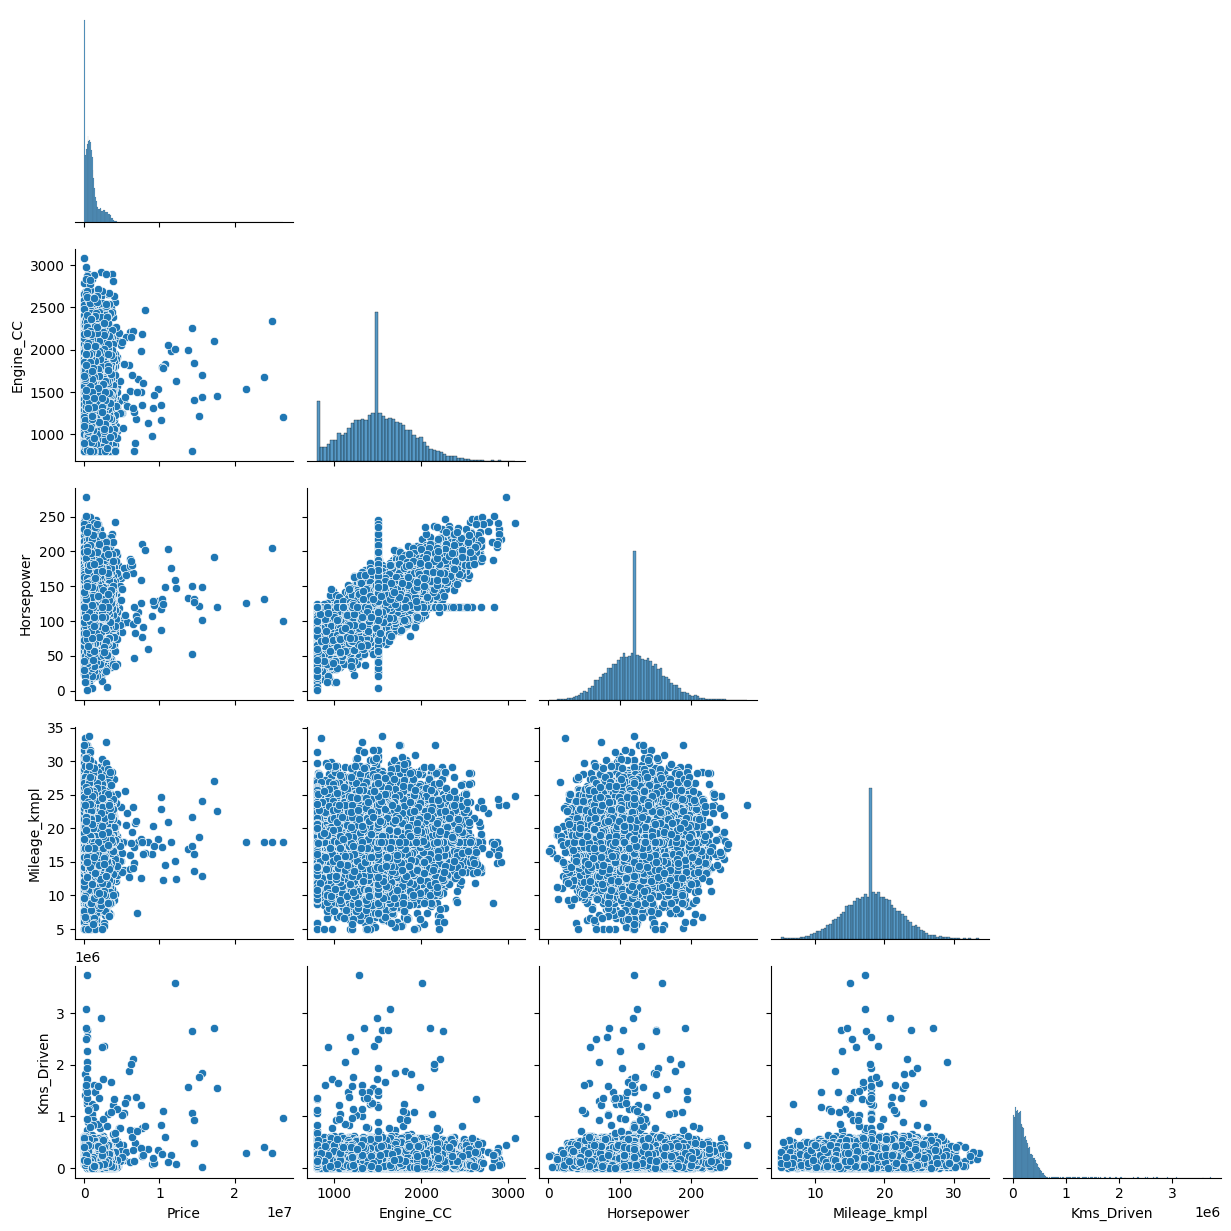

In [40]:
cols = [
    'Price',
    'Engine_CC',
    'Horsepower',
    'Mileage_kmpl',
    'Kms_Driven'
]

sns.pairplot(sample_df[cols], corner=True)
plt.show()

### 2. Correlation Heatmap

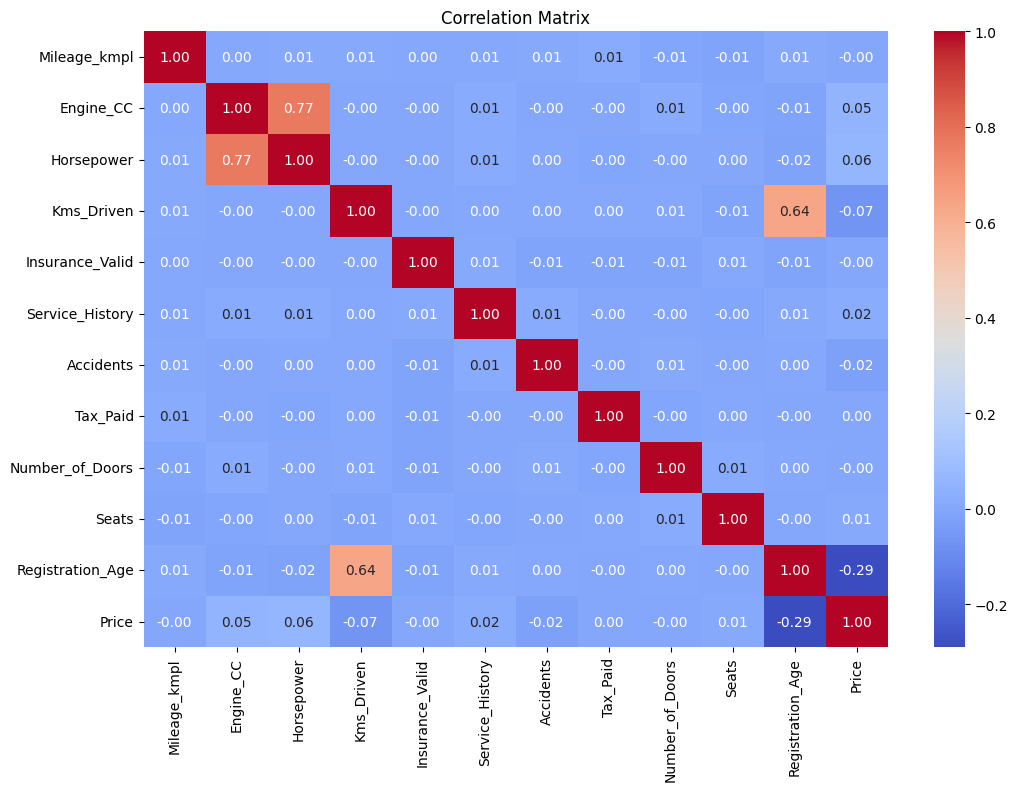

In [41]:
plt.figure(figsize=(12,8))

num_cols = sample_df.select_dtypes(include=['int64','float64']).columns

sns.heatmap(
    sample_df[num_cols].corr(),
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title("Correlation Matrix")
plt.show()

### 3. Scatter Plot with Hue

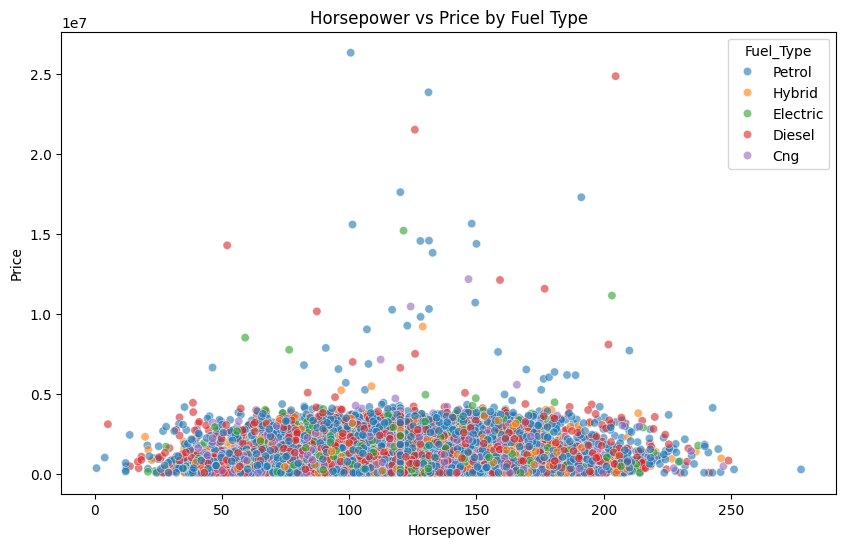

In [42]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    data=sample_df,
    x='Horsepower',
    y='Price',
    hue='Fuel_Type',
    alpha=0.6
)

plt.title("Horsepower vs Price by Fuel Type")
plt.show()

# 4. Feature Transformation

In [43]:
from sklearn.preprocessing import StandardScaler,OneHotEncoder
from sklearn.model_selection import train_test_split

## 4.1 Log Transformation

In [44]:
from scipy import stats
z_scores = np.abs(stats.zscore(df[num_cols]))

outliers = (z_scores > 3).sum()
print(outliers)

225609


In [45]:
# Columns that require log transformation
skew_cols = ['Price', 'Kms_Driven', 'Engine_CC']

# Apply log transformation
for col in skew_cols:
    df[col] = np.log1p(df[col])

print("Log transformation applied successfully!")

Log transformation applied successfully!


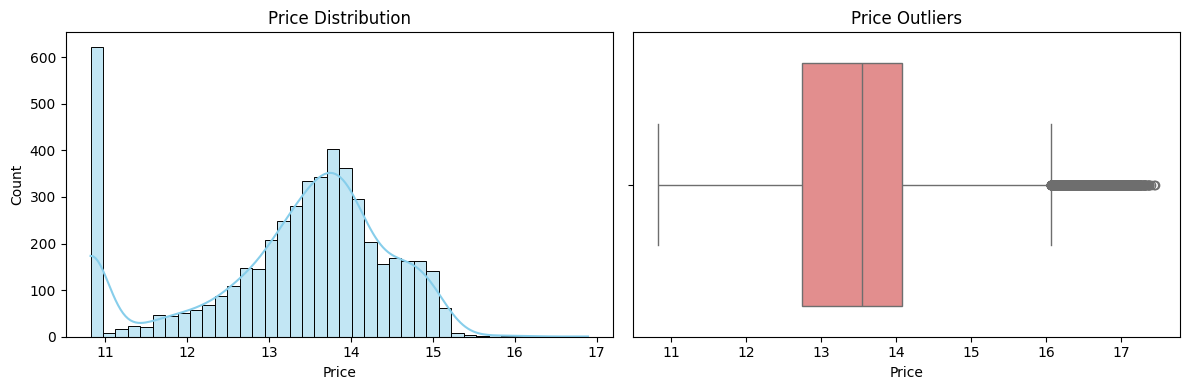

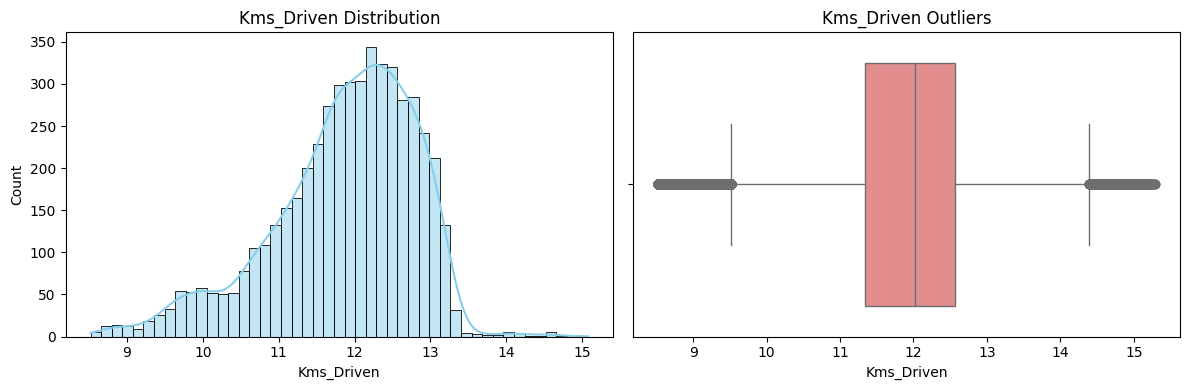

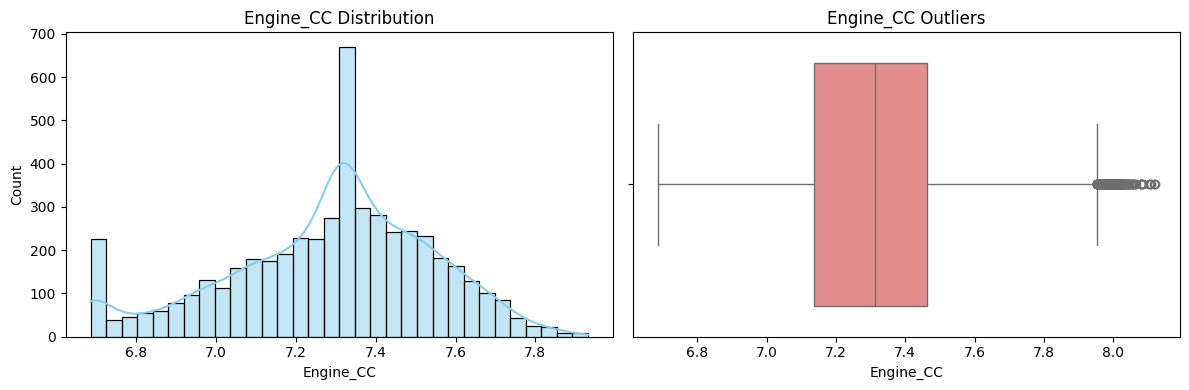

In [46]:
sample_df = df.sample(5000)
# Plot Histograms and Boxplots side-by-side for each numerical column
for col in skew_cols:
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    
    # Histogram with KDE curve
    sns.histplot(data=sample_df, x=col, kde=True, ax=axes[0], color='skyblue')
    axes[0].set_title(f'{col} Distribution')
    
    # Boxplot for outliers
    sns.boxplot(data=df, x=col, ax=axes[1], color='lightcoral')
    axes[1].set_title(f'{col} Outliers')
    
    plt.tight_layout()
    plt.show()

In [47]:
z_scores = np.abs(stats.zscore(df[num_cols]))

outliers = (z_scores > 3).sum()
print(outliers)

220951


## 4.2 One-Hot Encoding

In [48]:
# Converting continuous into categorical
df["Mileage_Category"] = pd.cut(
    df["Mileage_kmpl"],
    bins=4,
    labels=["Low", "Medium", "High", "Very High"]
)

#### Equal-width bins
| Mileage Range | Category  |
| ------------- | --------- |
| 5.00 – 12.82  | Low       |
| 12.82 – 20.64 | Medium    |
| 20.64 – 28.46 | High      |
| 28.46 – 36.28 | Very High |


In [49]:
bins = [0, 1000, 1500, 2000, 3000, float("inf")]
labels = ["Small", "Compact", "Mid-size", "Large", "Performance"]

df["Engine_Category"] = pd.cut(
    df["Engine_CC"],
    bins=bins,
    labels=labels
)

#### Equal-width bins

| Engine CC | Category           |
| --------- | ------------------ |
| < 1000    | Small              |
| 1000–1499 | Compact            |
| 1500–1999 | Mid-size           |
| 2000–2999 | Large              |
| ≥ 3000    | Performance/Luxury |


In [50]:
df.shape

(1000000, 21)

In [51]:
df = df.drop(columns = ['Mileage_kmpl','Engine_CC'])

In [52]:
df.shape

(1000000, 19)

In [53]:
categorical_cols = df.select_dtypes(include=['object', 'category']).columns

df = pd.get_dummies(
    df,
    columns=categorical_cols,
    drop_first=True,
    dtype=int
)

### Splitting Data before Feature scaling

In [54]:
X = df.drop('Price', axis=1)
y = df['Price']

In [55]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

## 4.3 Standard Scaling

In [56]:
# Implement StandardScaler to eliminate scaling bias across numerical features.

all_numeric_cols  = X_train.select_dtypes(include='number').columns # keep only non-binary numeric columns and scale them

cols_to_scale  = [c for c in all_numeric_cols  if df[c].nunique() > 2]

scaler = StandardScaler()

X_train[cols_to_scale] = scaler.fit_transform(X_train[cols_to_scale])

# Transform ONLY if using fit_transform so X_test uses it's own mean value
X_test[cols_to_scale] = scaler.transform(X_test[cols_to_scale])

In [57]:
X_train = pd.DataFrame(X_train)
X_train.head(2)

,Horsepower,Kms_Driven,Insurance_Valid,Service_History,Accidents,Tax_Paid,Number_of_Doors,Seats,Registration_Age,Brand_BMW,...,City_Kolkata,City_Mumbai,City_Pune,Mileage_Category_Medium,Mileage_Category_High,Mileage_Category_Very High,Engine_Category_Compact,Engine_Category_Mid-size,Engine_Category_Large,Engine_Category_Performance
569380,-0.01,-0.52,1,1,-0.55,1,-3.22,-0.18,-0.55,0,...,0,0,1,1,0,0,0,0,0,0
383753,-0.01,-0.17,1,1,-0.55,1,1.08,-0.18,-0.97,0,...,0,0,1,0,1,0,0,0,0,0


In [58]:
df.shape

(1000000, 88)

# 5. Machine Learning and Hyperparameter Tuning

In [59]:
from sklearn.model_selection import RandomizedSearchCV,KFold, cross_val_score

# Linear Models
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Lasso
from sklearn.linear_model import Ridge
from sklearn.linear_model import ElasticNet

# Tree-Based Models
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

# Boosting Models
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor

# Metrics
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

In [60]:
models = {

    # ============================
    # Linear Models (Baseline)
    # ============================
    "Linear Regression": LinearRegression(
        n_jobs=-1  # if supported by your sklearn version
    ),

    "Ridge Regression": Ridge(),

    "Lasso Regression": Lasso(),

    "ElasticNet": ElasticNet(),

    # ============================
    # Tree-Based Models
    # ============================
    "Decision Tree": DecisionTreeRegressor(
        random_state=42
    ),

    # ============================
    # Boosting Models (CPU)
    # ============================
    "XGBoost": XGBRegressor(
        random_state=42,
        objective='reg:squarederror',
        tree_method='hist',   # CPU-optimized
        n_jobs=-1
    ),

    "LightGBM": LGBMRegressor(
        random_state=42,
        force_col_wise=True,
        verbose=-1,
        n_jobs=1
    )
}

In [61]:
param_grids = {
    "Linear Regression": {},

    "Ridge Regression": {
        "alpha": [0.1, 1.0, 10, 50, 100]
    },

    "Lasso Regression": {
        "alpha": [0.001, 0.01, 0.1, 1, 10]
    },

    "ElasticNet": {
        "alpha": [0.001, 0.01, 0.1, 1],
        "l1_ratio": [0.2, 0.5, 0.8]
    },

    "Decision Tree": {
        "max_depth": [3, 5, 10, 15],
        "min_samples_split": [2, 5, 10],
        "min_samples_leaf": [1, 2, 5]
    },


    "XGBoost": {
        "n_estimators": [100, 300, 500],
        "max_depth": [3, 5, 7],
        "learning_rate": [0.01, 0.05, 0.1],
        "subsample": [0.7, 0.8, 1],
        "colsample_bytree": [0.7, 0.8, 1]
    },

    "LightGBM": {
    "n_estimators": [100, 200, 300],
    "learning_rate": [0.03, 0.05, 0.1],
    "num_leaves": [15, 31, 50],
    "max_depth": [3, 5, 7, 10],
    "min_child_samples": [10, 20]
    }
}

In [62]:
kf = KFold(n_splits=5, shuffle=True, random_state=42)

In [63]:
best_model = None
best_score = -float("inf")
best_model_name = ""

results = {}

for name, model in models.items():

    print(f"\nRunning GridSearchCV for {name}...")

    random_search = RandomizedSearchCV(
    estimator=model,
    param_distributions=param_grids[name],
    cv=kf,
    scoring='r2',
    n_jobs=-1,
    n_iter=10,
    random_state=42
    )

    random_search.fit(X_train, y_train)

    results[name] = {
        "Best Params": random_search.best_params_,
        "Best CV Score (R2)": random_search.best_score_
    }

    print(name)
    print("Best Params:", random_search.best_params_)
    print("Best CV Score (R2):", random_search.best_score_)

    # STORE ONLY BEST MODEL
    if random_search.best_score_ > best_score:
        best_score = random_search.best_score_
        best_model = random_search.best_estimator_
        best_model_name = name


Running GridSearchCV for Linear Regression...


/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_search.py:317: UserWarning: The total space of parameters 1 is smaller than n_iter=10. Running 1 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


Linear Regression
Best Params: {}
Best CV Score (R2): 0.5978056575974481

Running GridSearchCV for Ridge Regression...


/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_search.py:317: UserWarning: The total space of parameters 5 is smaller than n_iter=10. Running 5 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


Ridge Regression
Best Params: {'alpha': 10}
Best CV Score (R2): 0.597805663012349

Running GridSearchCV for Lasso Regression...


...

Lasso Regression
Best Params: {'alpha': 0.001}
Best CV Score (R2): 0.5976527452318777

Running GridSearchCV for ElasticNet...
ElasticNet
Best Params: {'l1_ratio': 0.2, 'alpha': 0.001}
Best CV Score (R2): 0.5976815635921785

Running GridSearchCV for Decision Tree...
Decision Tree
Best Params: {'min_samples_split': 10, 'min_samples_leaf': 5, 'max_depth': 15}
Best CV Score (R2): 0.6750105996412661

Running GridSearchCV for XGBoost...


/usr/local/lib/python3.12/dist-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


XGBoost
Best Params: {'subsample': 1, 'n_estimators': 500, 'max_depth': 5, 'learning_rate': 0.1, 'colsample_bytree': 0.8}
Best CV Score (R2): 0.693279687878265

Running GridSearchCV for LightGBM...


/usr/local/lib/python3.12/dist-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


LightGBM
Best Params: {'num_leaves': 31, 'n_estimators': 300, 'min_child_samples': 10, 'max_depth': 10, 'learning_rate': 0.1}
Best CV Score (R2): 0.6930797774936487


In [64]:
# DataFram of results to make it more readable
results_df = pd.DataFrame(results).T
results_df.sort_values(by="Best CV Score (R2)", ascending=False)

,Best Params,Best CV Score (R2)
XGBoost,"{'subsample': 1, 'n_estimators': 500, 'max_dep...",0.69
LightGBM,"{'num_leaves': 31, 'n_estimators': 300, 'min_c...",0.69
Decision Tree,"{'min_samples_split': 10, 'min_samples_leaf': ...",0.68
Ridge Regression,{'alpha': 10},0.60
Linear Regression,{},0.60
ElasticNet,"{'l1_ratio': 0.2, 'alpha': 0.001}",0.60
Lasso Regression,{'alpha': 0.001},0.60


In [65]:
print("Best Model:", best_model_name)
print("Best CV Score (R2):", best_score)

Best Model: XGBoost
Best CV Score (R2): 0.693279687878265


In [66]:
y_pred = best_model.predict(X_test)

In [67]:
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("MAE:", mae)
print("RMSE:", rmse)
print("R2 Score:", r2)

MAE: 0.5175895468420013
RMSE: 0.669475440019359
R2 Score: 0.6944482061511261
